#### Importing important libraries

In [1]:
import pandas as pd
import numpy as np
from  scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

### Data Loading & Data Parsing

In [3]:
df = pd.read_csv('../data/sudan.csv')

##### Adding a country column

In [4]:
df["COUNTRY"] = ["SUDAN"] * len(df)

##### Convert the YEAR and DOY columns into a proper datetime column

In [5]:
df["DATETIME"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

##### Extracting Month into its own column

In [15]:
df["YEAR_MONTH"] = df["DATETIME"].dt.to_period("M")

In [16]:
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,COUNTRY,DATETIME,YEAR_MONTH
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,SUDAN,2015-01-01,2015-01
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,SUDAN,2015-01-02,2015-01
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,SUDAN,2015-01-03,2015-01
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,SUDAN,2015-01-04,2015-01
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,SUDAN,2015-01-05,2015-01


### Summary Statistics & Missing-Value Report

In [17]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,COUNTRY,DATETIME,YEAR_MONTH
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,SUDAN,2015-01-01,2015-01
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,SUDAN,2015-01-02,2015-01
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,SUDAN,2015-01-03,2015-01
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,SUDAN,2015-01-04,2015-01
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,SUDAN,2015-01-05,2015-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,27.89,34.69,21.67,13.02,0.0,14.47,3.66,5.11,96.47,3.52,SUDAN,2026-03-27,2026-03
4104,2026,87,28.73,36.61,21.34,15.27,0.0,9.75,3.21,4.40,96.35,2.44,SUDAN,2026-03-28,2026-03
4105,2026,88,30.06,38.89,21.15,17.74,0.0,11.63,2.41,3.87,96.10,3.12,SUDAN,2026-03-29,2026-03
4106,2026,89,32.50,41.53,23.61,17.92,0.0,14.06,2.81,4.87,95.93,4.18,SUDAN,2026-03-30,2026-03


In [18]:
df.duplicated().sum()

np.int64(0)

`we don't have -999(null) value in our data. So we don't need to replace it with np.nan`

`We don't have duplicated row, so no need to drop any`

In [19]:
df.isnull().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
COUNTRY        0
DATETIME       0
YEAR_MONTH     0
dtype: int64

##### Describe the dataset

In [20]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATETIME
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN


`The 75th percentile and the max value of PRECTOTCORR is also has great gap, which suggest there might be outline on PRECTOTCORR feature.`

##### Percentage of missing values per column

In [21]:
n = len(df)
for col in df.columns:
    print(f"{col}: {df[col].isna().sum() / n * 100:.2f}%")

YEAR: 0.00%
DOY: 0.00%
T2M: 0.00%
T2M_MAX: 0.00%
T2M_MIN: 0.00%
T2M_RANGE: 0.00%
PRECTOTCORR: 0.00%
RH2M: 0.00%
WS2M: 0.00%
WS2M_MAX: 0.00%
PS: 0.00%
QV2M: 0.00%
COUNTRY: 0.00%
DATETIME: 0.00%
YEAR_MONTH: 0.00%


### Outlier Detection & Basic Cleaning

##### Computing z-score for numerical columns

In [22]:
z_df = df.select_dtypes(include=[np.number]).apply(stats.zscore)

In [23]:
z_df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,-1.579631,-1.685342,-0.764625,-0.278192,-1.054609,1.256503,-0.210603,0.028617,-0.023308,-0.029200,0.725856,-0.365662
1,-1.579631,-1.675933,-1.033813,-0.598681,-1.119435,0.929083,-0.210603,-0.421811,0.726303,-0.044824,1.212941,-0.728342
2,-1.579631,-1.666524,-1.288047,-1.166924,-1.260875,0.389446,-0.210603,0.383806,1.466303,0.845744,1.587621,-0.295995
3,-1.579631,-1.657115,-2.052884,-2.142028,-1.695015,-0.241140,-0.210603,-0.576436,2.148641,1.408208,2.187109,-0.984472
4,-1.579631,-1.647706,-2.396847,-2.171577,-2.360958,0.747183,-0.210603,-0.547864,0.764745,0.517640,1.887365,-1.025453


##### Flagging out rows with |z-score| > 3, as they're outliers and report their count 

In [24]:
for col in z_df.columns:
    count = z_df[col][z_df[col].abs() > 3].shape[0]
    print(f"{col}: {count} outliers")

YEAR: 0 outliers
DOY: 0 outliers
T2M: 3 outliers
T2M_MAX: 6 outliers
T2M_MIN: 1 outliers
T2M_RANGE: 15 outliers
PRECTOTCORR: 71 outliers
RH2M: 3 outliers
WS2M: 4 outliers
WS2M_MAX: 3 outliers
PS: 21 outliers
QV2M: 0 outliers


Apply IQR(Inner Quartile Range) to cap the outliers.

`The Interquartile Range (IQR) capping method (often called Winsorization or "clamping") is a popular way to handle outliers without losing the sample size that comes with simply deleting rows.`

In [25]:
# apply IQR method to columns with outliers
for col in z_df.columns:
    count = z_df[col][z_df[col].abs() > 3].shape[0]
    if count > 3:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

In [26]:
z_df = df.select_dtypes(include=[np.number]).apply(stats.zscore)

In [27]:
for col in z_df.columns:
    count = z_df[col][z_df[col].abs() > 3].shape[0]
    print(f"{col}: {count} outliers")

YEAR: 0 outliers
DOY: 0 outliers
T2M: 3 outliers
T2M_MAX: 0 outliers
T2M_MIN: 1 outliers
T2M_RANGE: 0 outliers
PRECTOTCORR: 0 outliers
RH2M: 3 outliers
WS2M: 0 outliers
WS2M_MAX: 3 outliers
PS: 0 outliers
QV2M: 0 outliers


##### Export z dataset

In [46]:
df.to_csv('../data/sudan_cleaned.csv', index=False)

### Time Series Analysis

In [29]:
monthly_t2m = (
    df.groupby("YEAR_MONTH", as_index=False)["T2M"]
      .mean()
      .rename(columns={"T2M": "T2M_MONTHLY_AVG"})
)

In [30]:
monthly_t2m.head()

,YEAR_MONTH,T2M_MONTHLY_AVG
0,2015-01,20.860323
1,2015-02,25.979643
2,2015-03,29.602581
3,2015-04,29.483000
4,2015-05,34.584516


In [31]:
warm_idx = monthly_t2m["T2M_MONTHLY_AVG"].idxmax()
cool_idx = monthly_t2m["T2M_MONTHLY_AVG"].idxmin()

warm_row = monthly_t2m.loc[warm_idx]
cool_row = monthly_t2m.loc[cool_idx]

##### Plot of monthly average T2M as a line chart over the full period

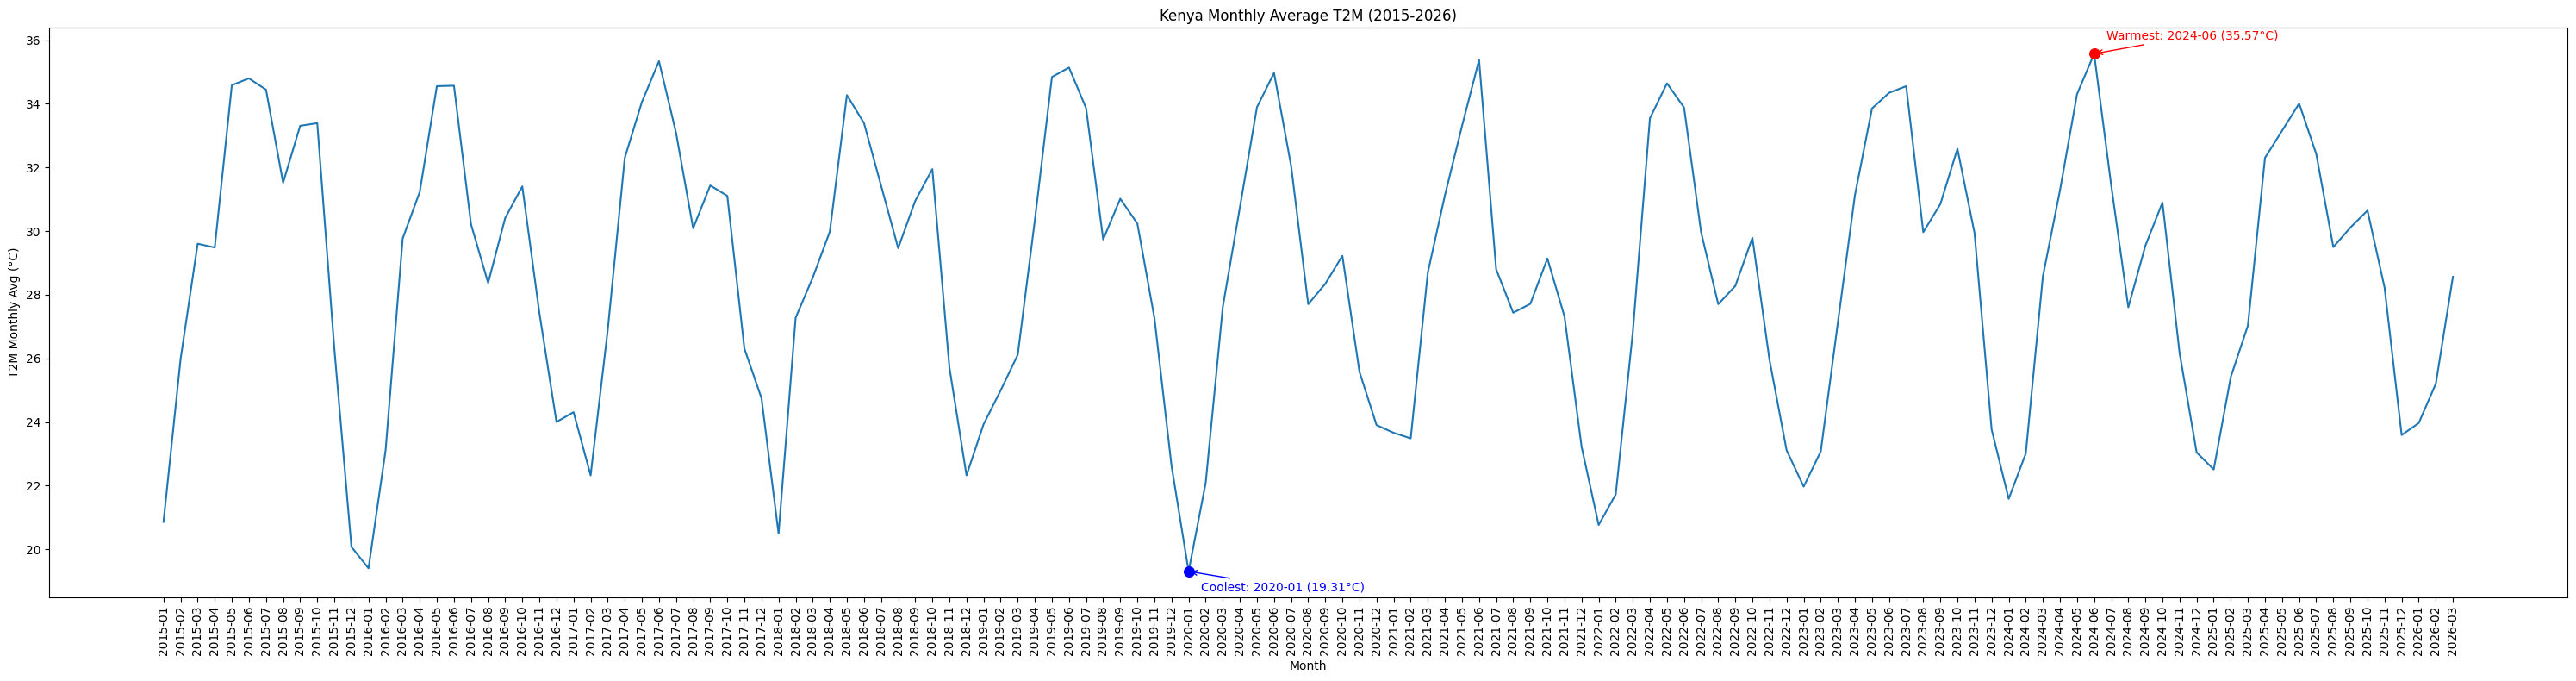

In [32]:
plt.figure(figsize=(30, 8))
x = monthly_t2m["YEAR_MONTH"].astype(str)
y = monthly_t2m["T2M_MONTHLY_AVG"]

plt.plot(x, y)

plt.scatter(x.iloc[warm_idx], y.iloc[warm_idx], color="red", s=70, zorder=5)
plt.scatter(x.iloc[cool_idx], y.iloc[cool_idx], color="blue", s=70, zorder=5)

# annotate warmest
plt.annotate(
    f"Warmest: {x.iloc[warm_idx]} ({y.iloc[warm_idx]:.2f}°C)",
    xy=(x.iloc[warm_idx], y.iloc[warm_idx]),
    xytext=(10, 12),
    textcoords="offset points",
    color="red",
    arrowprops=dict(arrowstyle="->", color="red")
)

# annotate coolest
plt.annotate(
    f"Coolest: {x.iloc[cool_idx]} ({y.iloc[cool_idx]:.2f}°C)",
    xy=(x.iloc[cool_idx], y.iloc[cool_idx]),
    xytext=(10, -16),
    textcoords="offset points",
    color="blue",
    arrowprops=dict(arrowstyle="->", color="blue")
)

plt.title("Kenya Monthly Average T2M (2015-2026)")
plt.xlabel("Month")
plt.ylabel("T2M Monthly Avg (°C)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

##### Plot monthly total PRECTOTCORR as a bar chart. 

In [33]:
monthly_prectotcorr = (
    df.groupby("YEAR_MONTH", as_index=False)["PRECTOTCORR"]
    .mean()
    .rename(columns={"PRECTOTCORR": "PRECTOTCORR_MONTHLY_AVG"}))

In [34]:
monthly_prectotcorr.head()

,YEAR_MONTH,PRECTOTCORR_MONTHLY_AVG
0,2015-01,0.000000
1,2015-02,0.000000
2,2015-03,0.000000
3,2015-04,0.000000
4,2015-05,0.000806


In [35]:
peak_rain_idx = monthly_prectotcorr["PRECTOTCORR_MONTHLY_AVG"].idxmax()

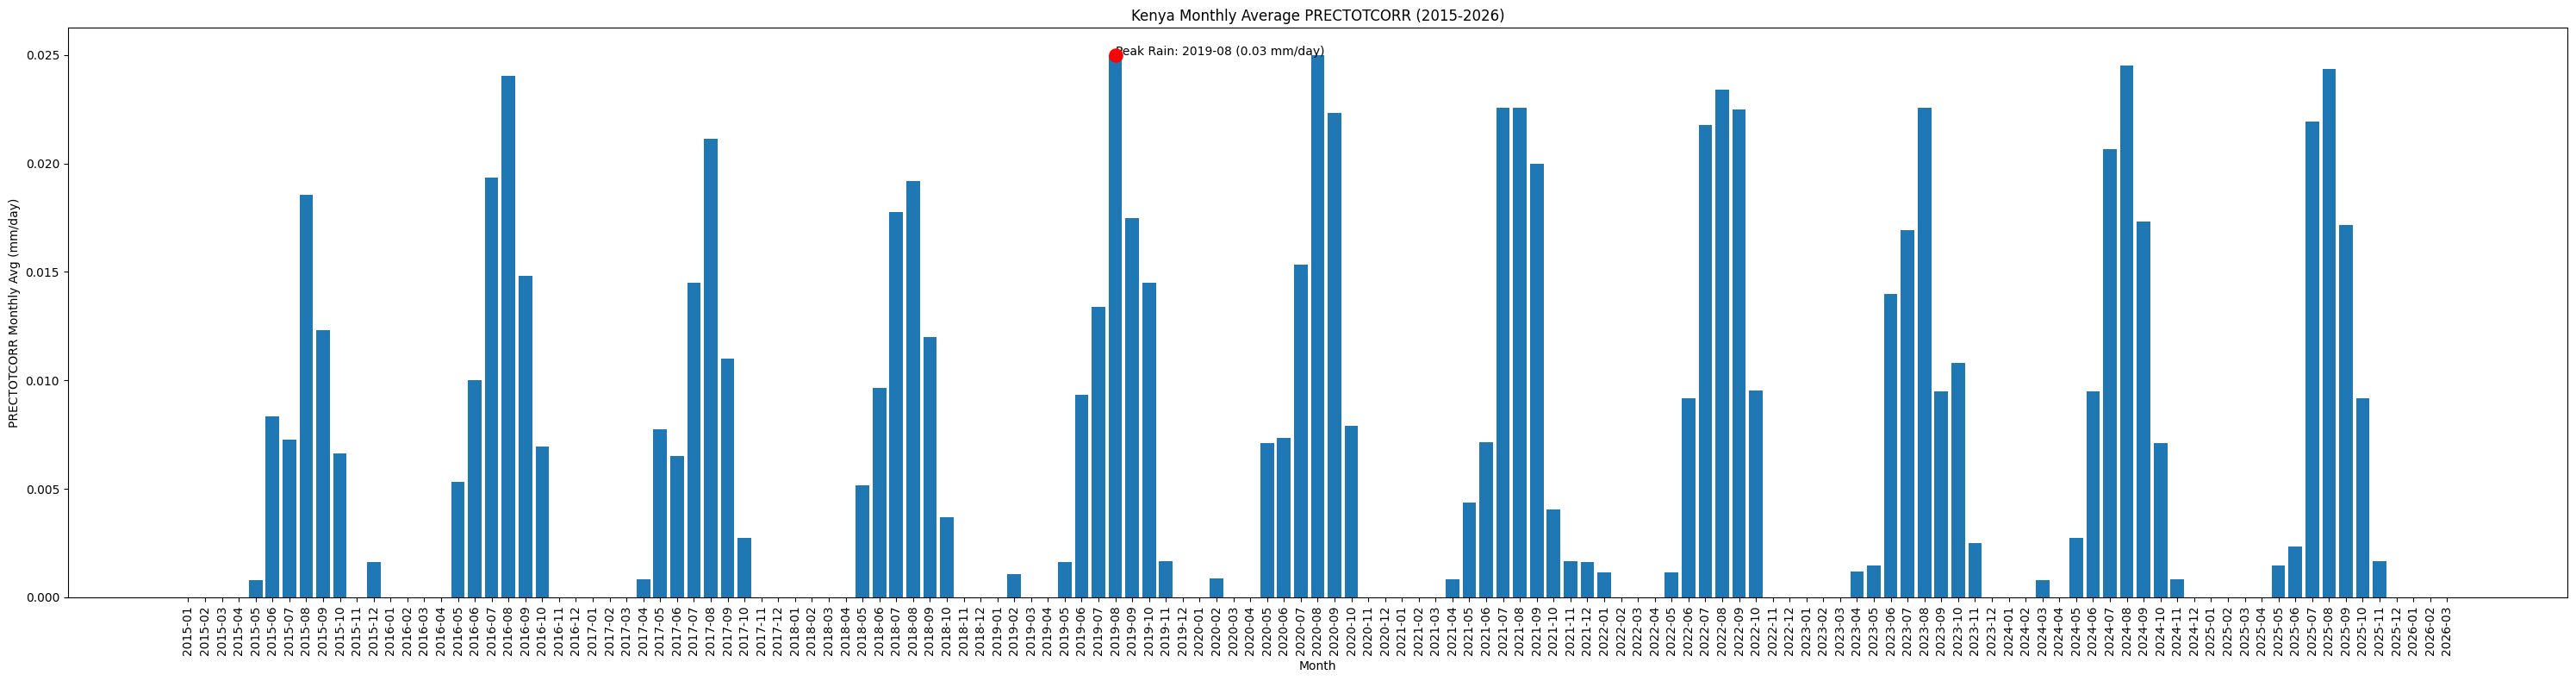

In [36]:
plt.figure(figsize=(30, 8))

plt.bar(
    monthly_prectotcorr["YEAR_MONTH"]
    .astype(str), monthly_prectotcorr["PRECTOTCORR_MONTHLY_AVG"]
    )

plt.scatter(
    monthly_prectotcorr["YEAR_MONTH"].astype(str).iloc[peak_rain_idx], 
    monthly_prectotcorr["PRECTOTCORR_MONTHLY_AVG"].iloc[peak_rain_idx], 
    color="red", s=120, zorder=5
)
plt. annotate(
    f"Peak Rain: {monthly_prectotcorr['YEAR_MONTH'].astype(str).iloc[peak_rain_idx]} ({monthly_prectotcorr['PRECTOTCORR_MONTHLY_AVG'].iloc[peak_rain_idx]:.2f} mm/day)",
    xy=(monthly_prectotcorr["YEAR_MONTH"].astype(str).iloc[peak_rain_idx], monthly_prectotcorr["PRECTOTCORR_MONTHLY_AVG"].iloc[peak_rain_idx]),
    )
plt.title("Kenya Monthly Average PRECTOTCORR (2015-2026)")
plt.xlabel("Month")
plt.ylabel("PRECTOTCORR Monthly Avg (mm/day)")
plt.xticks(rotation=90)
plt.tight_layout()

`The temperature fluctuation trend of the year seems to repeat itself year after year.`

`Months with high or low precipitation are uniform among years`

### Correlation & Relationship Analysis

##### Heatmap of correlations across all numeric columns

<Axes: >

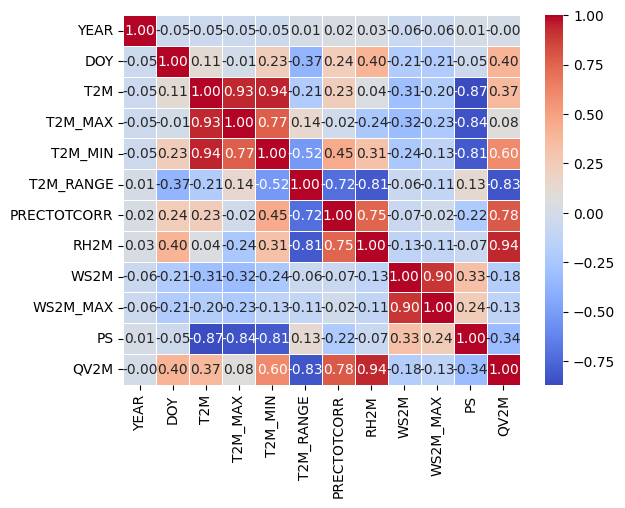

In [37]:
num_df = df.select_dtypes(include=[np.number])

corr = num_df.corr()

# heatmap of correlation matrix
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

`The three strongest correlations:`
`T2M_MIN and T2M == 0.94`
`QV2M and RH2M == 0.94`
`T2M and T2M_MAX == 0.93`


##### Scatter plots: T2M vs. RH2M; T2M_RANGE vs. WS2M

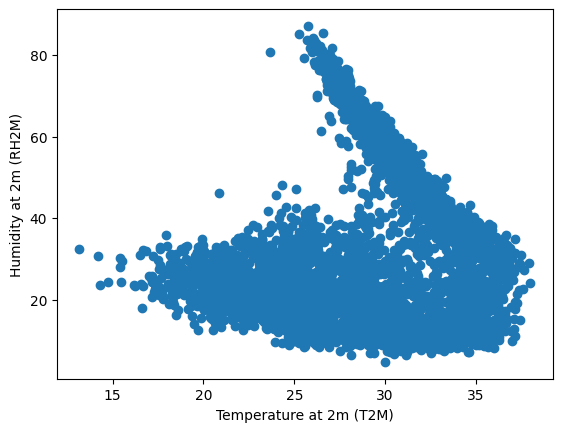

In [38]:
plt.scatter(df["T2M"], df["RH2M"])
plt.xlabel("Temperature at 2m (T2M)")
plt.ylabel("Humidity at 2m (RH2M)");

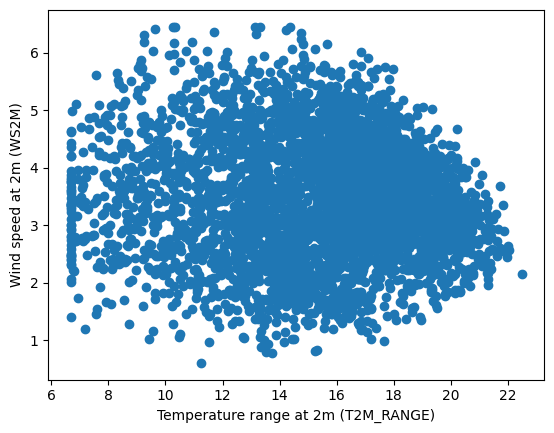

In [39]:
plt.scatter(df["T2M_RANGE"], df["WS2M"])
plt.xlabel("Temperature range at 2m (T2M_RANGE)")
plt.ylabel("Wind speed at 2m (WS2M)");  

### Distribution Analysis

##### Histogram of PRECTOTCORR

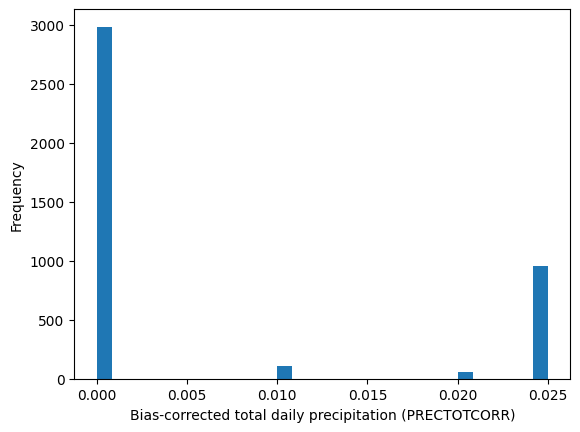

In [42]:
plt.hist(df["PRECTOTCORR"], bins=30)
plt.xlabel("Bias-corrected total daily precipitation (PRECTOTCORR)")
plt.ylabel("Frequency");

##### Applying log scaling since it's heavily skewed

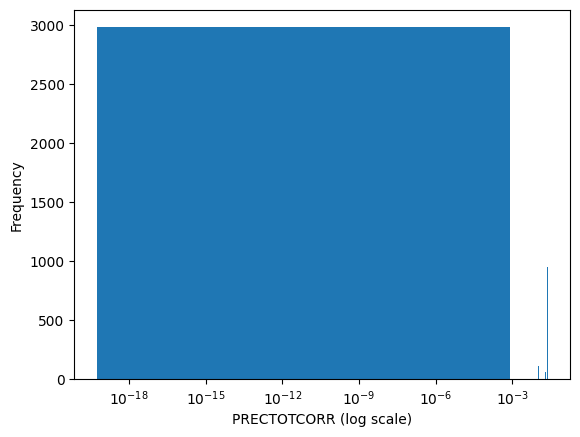

In [44]:
plt.hist(df["PRECTOTCORR"], bins=30)
plt.xscale("log")
plt.xlabel("PRECTOTCORR (log scale)")
plt.ylabel("Frequency");

##### Bubble chart: T2M vs. RH2M, bubble size = PRECTOTCORR.

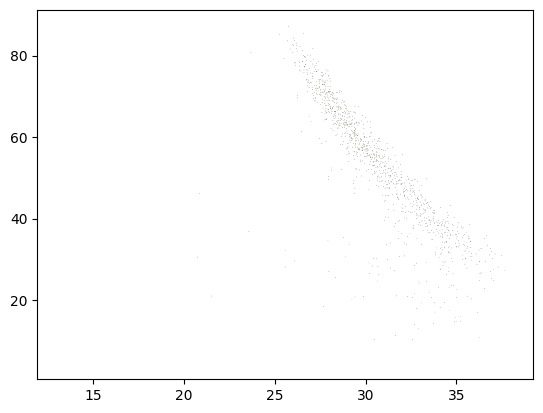

In [45]:
plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"],
    c=df["PRECTOTCORR"],   # optional: color by same variable
    cmap="viridis",
    edgecolors="k",
    linewidths=0.2
)